In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
x= np.array([1,2,3,4])
y= np.array([2,2.8,3.6,4.5])

In [4]:
y

array([2. , 2.8, 3.6, 4.5])

In [5]:
w = 0
b = 0
alpha = 0.01
num_iteration = 20


In [6]:
sse_values = []

#Gradient descent

for i in range(num_iteration):
    
    y_hat = w*x + b
    
    D_w = 2 * np.sum((y_hat -y)*x)####gradient of w 
    D_b = 2 * np.sum(y_hat-y)### gradient of  b 
    
    #Update parameters
    w -= alpha * D_w
    b -= alpha * D_b
    
    #compute sse and store it on sse variable
    sse = (np.sum((y_hat -y)**2))
    sse_values.append(sse)
    
    if (i+1)  % 20 == 0 :
        print(f"iteration {i+1}, SSE: {sse}")
    
    

iteration 20, SSE: 0.2586443145721848


In [7]:

print(f"Optimized parameters: bais = {b}, slop = {w}")

Optimized parameters: bais = 0.5388025938800368, slop = 1.0378816512559883


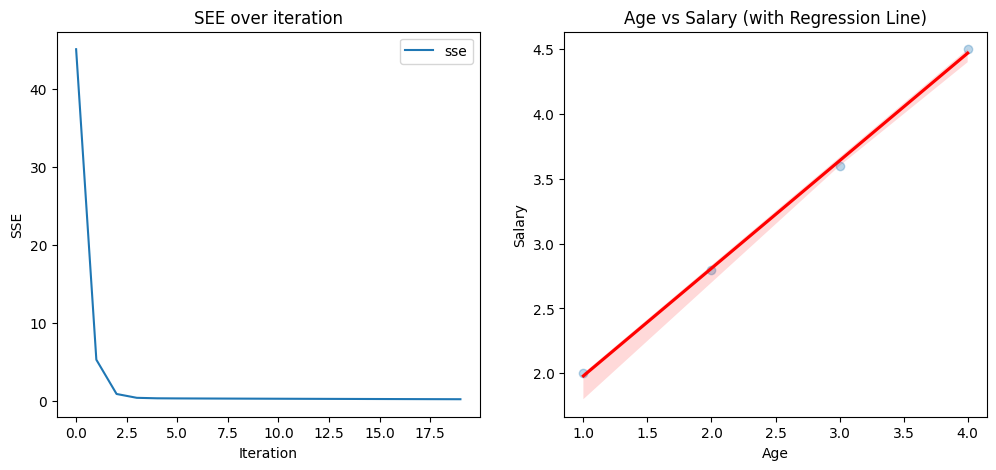

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(num_iteration),sse_values,label='sse')
plt.xlabel("Iteration")
plt.ylabel('SSE')
plt.title('SEE over iteration')
plt.legend()
# plt.show()

plt.subplot(1,2,2) 
sns.regplot(x=x, y=y, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}) 
plt.xlabel("Age") 
plt.ylabel("Salary") 
plt.title("Age vs Salary (with Regression Line)") 
plt.show()


In [9]:
y=w * x + b
y

array([1.57668425, 2.6145659 , 3.65244755, 4.6903292 ])

In [10]:
class LReg:

    def __init__(self, alpha, num_iterations):
        self.alpha = alpha
        self.num_iterations = num_iterations
        self.w = 0
        self.b = 0
        self.sse_values = []
        self.y_hat = None

    def predict(self, x):
        y_hat = self.w * x + self.b
        self.y_hat = y_hat
        return y_hat

    # def gradiant_decent(self, x , y , y_hat):
    #     delta_w = np.mean(y_hat - y)* x
    #     delta_b = np.mean(y_hat - y)

    def gradient_descent(self, x, y, y_hat):
        delta_w = np.mean((y_hat - y) * x)
        delta_b = np.mean(y_hat - y)
        return delta_w, delta_b


    def calculate_sse(self, y , y_hat):
        sse = (np.sum((y_hat -y)**2))
        return sse
    
    def fit(self, x , y):

        for i in range(self.num_iterations):
            y_hat = self.predict(x)
            dw,db = self.gradient_descent(x , y , y_hat)

            self.w -= self.alpha * dw
            self.b -= self.alpha * db

            sse = self.calculate_sse(y , y_hat)
            self.sse_values.append(sse)
            if (i+1) % 20 == 0:
                print(f"iteration {i+1}: sse is equal to {sse}")

        return self
 
    def plot(self , x , y):
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(range(self.num_iterations),self.sse_values,label='sse')
        plt.xlabel("Iteration")
        plt.ylabel('SSE')
        plt.title('SEE over iteration')
        plt.legend()
        # plt.show()

        plt.subplot(1,2,2) 
        sns.regplot(x=x, y=y, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}) 
        plt.xlabel("Age") 
        plt.ylabel("Salary") 
        plt.title("Age vs Salary (with Regression Line)") 
        plt.show()



In [11]:
df = pd.read_csv('Employee.csv')

df.head()


x = df['Age']
y = df['Salary']

y.head()
df.describe()
# x = np.array([1,2,3,4])
# y = np.array([2,2.2,3.6,4.5])


print(df['Age'].mean())  
print(df['Salary'].mean())


28.989795918367346
112956.49795918367


iteration 20: sse is equal to 12053368054997.506


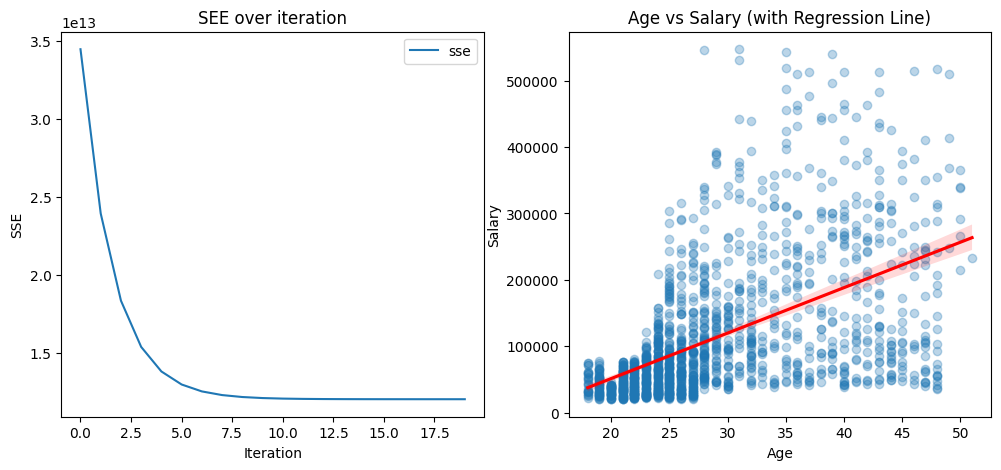

In [12]:
l = LReg(alpha = 0.0003, num_iterations = 20)
l.fit(x,y)
l.plot(x,y)

In [13]:
print("Final slope (w):", l.w) 
print("Final intercept (b):", l.b)


Final slope (w): 4093.9028163653056
Final intercept (b): 95.02970375586541


In [14]:
corr = np.corrcoef(df["Age"], df["Salary"])[0,1] 
print("Correlation between Age and Salary:", corr)

Correlation between Age and Salary: 0.5292271428412809


In [ ]:
x = np.array([50,60,70,80,90])
y = np.array([150 , 180 , 210 , 240 , 270])
learning_rate = 0.0001
n_iters = 10000


lin_reg = LReg(learning_rate , n_iters)

lin_reg.fit(x , y)

y_predict = lin_reg.predict(x)
print(y_predict)


test_value = np.array([30,40,100])

y_test = lin_reg.predict(test_value)


print(f"the best fit line equation is")
print(y_test)








iteration 20: sse is equal to 0.0003326662816090481
iteration 40: sse is equal to 0.0003322295832521807
iteration 60: sse is equal to 0.00033217748260532887
iteration 80: sse is equal to 0.00033212539013351047
iteration 100: sse is equal to 0.00033207330582760326
iteration 120: sse is equal to 0.00033202122968999586
iteration 140: sse is equal to 0.0003319691617194517
iteration 160: sse is equal to 0.0003319171019139557
iteration 180: sse is equal to 0.0003318650502726392
iteration 200: sse is equal to 0.0003318130067936708
iteration 220: sse is equal to 0.0003317609714781535
iteration 240: sse is equal to 0.0003317089443216428
iteration 260: sse is equal to 0.00033165692532221663
iteration 280: sse is equal to 0.0003316049144825826
iteration 300: sse is equal to 0.0003315529118007265
iteration 320: sse is equal to 0.0003315009172713808
iteration 340: sse is equal to 0.0003314489308965657
iteration 360: sse is equal to 0.00033139695267518415
iteration 380: sse is equal to 0.00033134498